# Analyze GRPO Reward Learning

This notebook summarizes the reward log for a GRPO causal-discovery run and checks whether the model shows meaningful learning over time.

Main questions:
- Does `cd_graph_reward` improve over generations?
- Does formatting improve?
- Does the zero-reward rate fall?
- Are late generations better than early generations?

In [1]:
from pathlib import Path
import json
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
reward_log_path = Path('/home/yuen_chen/ENCO/experiments/checkpoints/grpo_sachs_mix_onthefly_mp2/grpo_log/reward_responses_rank0.jsonl')
assert reward_log_path.exists(), reward_log_path

rows = [json.loads(line) for line in reward_log_path.open() if line.strip()]
len(rows)

1080

In [3]:
df = pd.DataFrame([
    {
        'generation_idx': r['generation_idx'],
        'sample_idx': r['sample_idx'],
        'format_ok': r.get('format_ok', 0),
        'reward_total': r.get('reward_total', 0.0),
        'cd_graph_reward': r.get('rewards', {}).get('cd_graph_reward', 0.0),
        'cd_format_reward': r.get('rewards', {}).get('cd_format_reward', 0.0),
        'cd_partial_format_reward': r.get('rewards', {}).get('cd_partial_format_reward', 0.0),
    }
    for r in rows
])

df['cd_positive'] = (df['cd_graph_reward'] > 0).astype(int)
df['cd_zero'] = (df['cd_graph_reward'] == 0).astype(int)
df

,generation_idx,sample_idx,format_ok,reward_total,cd_graph_reward,cd_format_reward,cd_partial_format_reward,cd_positive,cd_zero
0,0,0,0,0.000000,0.000000,0.0,0.00,0,1
1,0,1,0,0.000000,0.000000,0.0,0.00,0,1
2,1,0,0,0.000000,0.000000,0.0,0.00,0,1
3,1,1,0,0.000000,0.000000,0.0,0.00,0,1
4,2,0,0,0.508535,0.418535,0.0,0.09,1,0
...,...,...,...,...,...,...,...,...,...
1075,537,1,1,0.240000,0.000000,0.2,0.04,0,1
1076,538,0,1,0.240000,0.000000,0.2,0.04,0,1
1077,538,1,0,0.040000,0.000000,0.0,0.04,0,1
1078,539,0,1,0.240000,0.000000,0.2,0.04,0,1


## Overall summary

In [4]:
overall = pd.Series({
    'rows': len(df),
    'num_generations': df['generation_idx'].nunique(),
    'cd_graph_reward_mean': df['cd_graph_reward'].mean(),
    'reward_total_mean': df['reward_total'].mean(),
    'format_ok_rate': df['format_ok'].mean(),
    'cd_positive_rate': df['cd_positive'].mean(),
    'cd_zero_rate': df['cd_zero'].mean(),
    'strict_format_reward_mean': df['cd_format_reward'].mean(),
    'partial_format_reward_mean': df['cd_partial_format_reward'].mean(),
})
overall

rows                          1080.000000
num_generations                540.000000
cd_graph_reward_mean             0.126313
reward_total_mean                0.251813
format_ok_rate                   0.411111
cd_positive_rate                 0.335185
cd_zero_rate                     0.663889
strict_format_reward_mean        0.082222
partial_format_reward_mean       0.043278
dtype: float64

In [5]:
df = pd.DataFrame([
    {
        "generation_idx": r["generation_idx"],
        "sample_idx": r["sample_idx"],
        "format_ok": r.get("format_ok", 0),
        "reward_total": r.get("reward_total", 0.0),
        "cd_graph_reward": r.get("rewards", {}).get("cd_graph_reward", 0.0),
        "cd_format_reward": r.get("rewards", {}).get("cd_format_reward", 0.0),
        "cd_partial_format_reward": r.get("rewards", {}).get("cd_partial_format_reward", 0.0),
    }
    for r in rows
])

df["cd_positive"] = (df["cd_graph_reward"] > 0).astype(int)
df["cd_zero"] = (df["cd_graph_reward"] == 0).astype(int)
df.head()




,generation_idx,sample_idx,format_ok,reward_total,cd_graph_reward,cd_format_reward,cd_partial_format_reward,cd_positive,cd_zero
0,0,0,0,0.000000,0.000000,0.0,0.00,0,1
1,0,1,0,0.000000,0.000000,0.0,0.00,0,1
2,1,0,0,0.000000,0.000000,0.0,0.00,0,1
3,1,1,0,0.000000,0.000000,0.0,0.00,0,1
4,2,0,0,0.508535,0.418535,0.0,0.09,1,0


## Aggregate by generation

Each generation has multiple samples. We average within generation to get a cleaner learning curve.

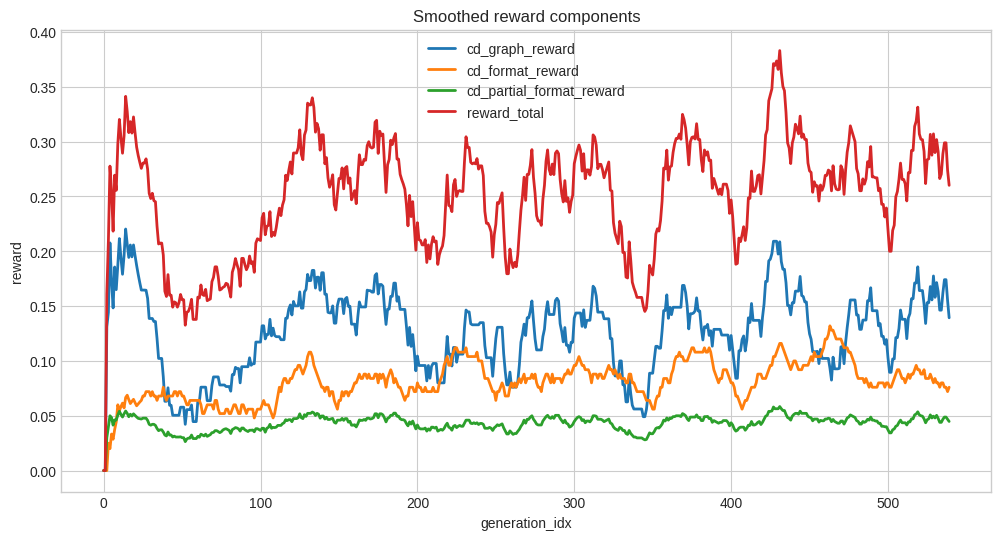

In [6]:
gen = (
    df.groupby('generation_idx', as_index=False)
      .agg(
          n=('sample_idx', 'count'),
          cd_graph_reward=('cd_graph_reward', 'mean'),
          reward_total=('reward_total', 'mean'),
          format_ok=('format_ok', 'mean'),
          cd_positive=('cd_positive', 'mean'),
          cd_zero=('cd_zero', 'mean'),
          cd_format_reward=('cd_format_reward', 'mean'),
          cd_partial_format_reward=('cd_partial_format_reward', 'mean'),
      )
)
reward_cols = [
    "cd_graph_reward",
    "cd_format_reward",
    "cd_partial_format_reward",
    "reward_total",
]

gen = (
    df.groupby("generation_idx", as_index=False)
      .agg(
          cd_graph_reward=("cd_graph_reward", "mean"),
          cd_format_reward=("cd_format_reward", "mean"),
          cd_partial_format_reward=("cd_partial_format_reward", "mean"),
          reward_total=("reward_total", "mean"),
      )
)

fig, ax = plt.subplots(figsize=(12, 6))
for col in reward_cols:
    ax.plot(
        gen["generation_idx"],
        gen[col].rolling(25, min_periods=1).mean(),
        label=col,
        linewidth=2,
    )

ax.set_xlabel("generation_idx")
ax.set_ylabel("reward")
ax.set_title("Smoothed reward components")
ax.legend()
plt.show()


## Early / middle / late comparison

In [7]:
third = len(df) // 3
segments = {
    "first": df.iloc[:third],
    "middle": df.iloc[third:2*third],
    "last": df.iloc[2*third:],
}

segment_summary = pd.DataFrame({
    name: {
        "num_rows": len(seg),
        "cd_graph_reward_mean": seg["cd_graph_reward"].mean(),
        "reward_total_mean": seg["reward_total"].mean(),
        "format_ok_rate": seg["format_ok"].mean(),
        "cd_positive_rate": seg["cd_positive"].mean(),
        "cd_zero_rate": seg["cd_zero"].mean(),
        "strict_format_reward_mean": seg["cd_format_reward"].mean(),
        "partial_format_reward_mean": seg["cd_partial_format_reward"].mean(),
    }
    for name, seg in segments.items()
}).T

segment_summary


,num_rows,cd_graph_reward_mean,reward_total_mean,format_ok_rate,cd_positive_rate,cd_zero_rate,strict_format_reward_mean,partial_format_reward_mean
first,360.0,0.125945,0.237972,0.350000,0.333333,0.663889,0.070000,0.042028
middle,360.0,0.117602,0.244491,0.425000,0.311111,0.688889,0.085000,0.041889
last,360.0,0.135392,0.272975,0.458333,0.361111,0.638889,0.091667,0.045917


## First-vs-last deltas

This makes the direction of change explicit.

In [8]:
(segment_summary.loc["last"] - segment_summary.loc["first"]).to_frame("last_minus_first")


,last_minus_first
num_rows,0.000000
cd_graph_reward_mean,0.009447
reward_total_mean,0.035003
format_ok_rate,0.108333
cd_positive_rate,0.027778
cd_zero_rate,-0.025000
strict_format_reward_mean,0.021667
partial_format_reward_mean,0.003889


## Relationship between formatting and graph reward

In [9]:
fmt_split = (
    df.groupby('format_ok')
      .agg(
          n=('sample_idx', 'count'),
          cd_graph_reward_mean=('cd_graph_reward', 'mean'),
          reward_total_mean=('reward_total', 'mean'),
          cd_positive_rate=('cd_positive', 'mean'),
          cd_zero_rate=('cd_zero', 'mean'),
      )
)
fmt_split

,n,cd_graph_reward_mean,reward_total_mean,cd_positive_rate,cd_zero_rate
format_ok,,,,,
0,636,0.098697,0.128886,0.262579,0.735849
1,444,0.165870,0.427897,0.439189,0.560811


## Rolling trends

We smooth the generation-level metrics to reduce batch noise.

## Best and worst generations by graph reward

In [10]:
best = gen.sort_values('cd_graph_reward', ascending=False).head(10)
worst = gen.sort_values('cd_graph_reward', ascending=True).head(10)

print('Best generations by cd_graph_reward')
display(best)

print('Worst generations by cd_graph_reward')
display(worst)

Best generations by cd_graph_reward


,generation_idx,cd_graph_reward,cd_format_reward,cd_partial_format_reward,reward_total
405,405,0.627063,0.1,0.09,0.817063
230,230,0.602532,0.1,0.09,0.792532
14,14,0.555960,0.2,0.09,0.845960
300,300,0.551515,0.2,0.09,0.841515
529,529,0.545876,0.0,0.08,0.625876
306,306,0.543739,0.1,0.09,0.733739
495,495,0.542045,0.1,0.09,0.732045
335,335,0.535198,0.2,0.09,0.825198
219,219,0.532500,0.2,0.09,0.822500
69,69,0.532374,0.1,0.09,0.722374


Worst generations by cd_graph_reward


,generation_idx,cd_graph_reward,cd_format_reward,cd_partial_format_reward,reward_total
261,261,0.0,0.0,0.00,0.00
258,258,0.0,0.1,0.02,0.12
257,257,0.0,0.0,0.02,0.02
256,256,0.0,0.0,0.02,0.02
255,255,0.0,0.0,0.00,0.00
254,254,0.0,0.2,0.04,0.24
253,253,0.0,0.1,0.02,0.12
252,252,0.0,0.1,0.02,0.12
271,271,0.0,0.0,0.04,0.04
269,269,0.0,0.0,0.02,0.02


## Multi-run report from `train_metrics.jsonl`

Use this section to compare the main pretrained-start GRPO runs directly from trainer metrics. Continuation runs are shown separately below.


In [11]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

PRETRAINED_RUNS = {
    "fresh_revised": Path("/home/yuen_chen/ENCO/experiments/checkpoints/grpo_sachs_mix_fresh_revised_seed2025/grpo_log/train_metrics.jsonl"),
    "onthefly_mp2": Path("/home/yuen_chen/ENCO/experiments/checkpoints/grpo_sachs_mix_onthefly_mp2/grpo_log/train_metrics.jsonl"),
    "obs1000_int50_balanced": Path("/home/yuen_chen/ENCO/experiments/checkpoints/grpo_sachs_obs1000_int50_balanced/grpo_log/train_metrics.jsonl"),
}

CONTINUATION_RUNS = {
    "continue_from_540": Path("/home/yuen_chen/ENCO/experiments/checkpoints/grpo_sachs_mix_onthefly_mp2_continue_from540/grpo_log/train_metrics.jsonl"),
}

def load_train_metrics(path: Path) -> pd.DataFrame:
    rows = [json.loads(line) for line in path.open() if line.strip()]
    df = pd.DataFrame(rows)
    if "reward" in df.columns:
        df = df[df["reward"].notna()].copy()
    if "global_step" in df.columns:
        df = df.sort_values("global_step").reset_index(drop=True)
    return df

main_run_dfs = {name: load_train_metrics(path) for name, path in PRETRAINED_RUNS.items() if path.exists()}
continuation_run_dfs = {name: load_train_metrics(path) for name, path in CONTINUATION_RUNS.items() if path.exists()}
list(main_run_dfs), list(continuation_run_dfs)


(['fresh_revised', 'onthefly_mp2', 'obs1000_int50_balanced'],
 ['continue_from_540'])

In [12]:
summary_rows = []

for name, df in main_run_dfs.items():
    first = df.iloc[0]
    last = df.iloc[-1]
    best_idx = df["reward"].idxmax()
    best = df.loc[best_idx]

    summary_rows.append({
        "run": name,
        "num_logged_steps": len(df),
        "first_global_step": first["global_step"],
        "last_global_step": last["global_step"],
        "first_reward": first["reward"],
        "best_reward": best["reward"],
        "best_reward_step": best["global_step"],
        "last_reward": last["reward"],
        "delta_last_minus_first": last["reward"] - first["reward"],
        "last_cd_graph_reward": last.get("rewards/cd_graph_reward/mean"),
        "best_cd_graph_reward": best.get("rewards/cd_graph_reward/mean"),
        "last_cd_format_reward": last.get("rewards/cd_format_reward/mean"),
        "last_length_penalty": last.get("rewards/length_penalty_reward/mean"),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("best_reward", ascending=False).reset_index(drop=True)
summary_df


,run,num_logged_steps,first_global_step,last_global_step,first_reward,best_reward,best_reward_step,last_reward,delta_last_minus_first,last_cd_graph_reward,best_cd_graph_reward,last_cd_format_reward,last_length_penalty
0,onthefly_mp2,54,10.0,540.0,-0.035586,0.111395,360.0,-0.007398,0.028188,0.087105,0.192874,0.095,-0.231503
1,fresh_revised,151,10.0,1510.0,-0.066564,0.093067,400.0,-0.236142,-0.169578,0.000000,0.074823,0.000,-0.236242
2,obs1000_int50_balanced,36,10.0,360.0,-0.163399,-0.058884,240.0,-0.083479,0.079920,0.000000,0.005556,0.055,-0.210979


### Reward curves

These plots are the easiest collaborator-facing view: show the raw reward and a smoothed reward trend for each run.


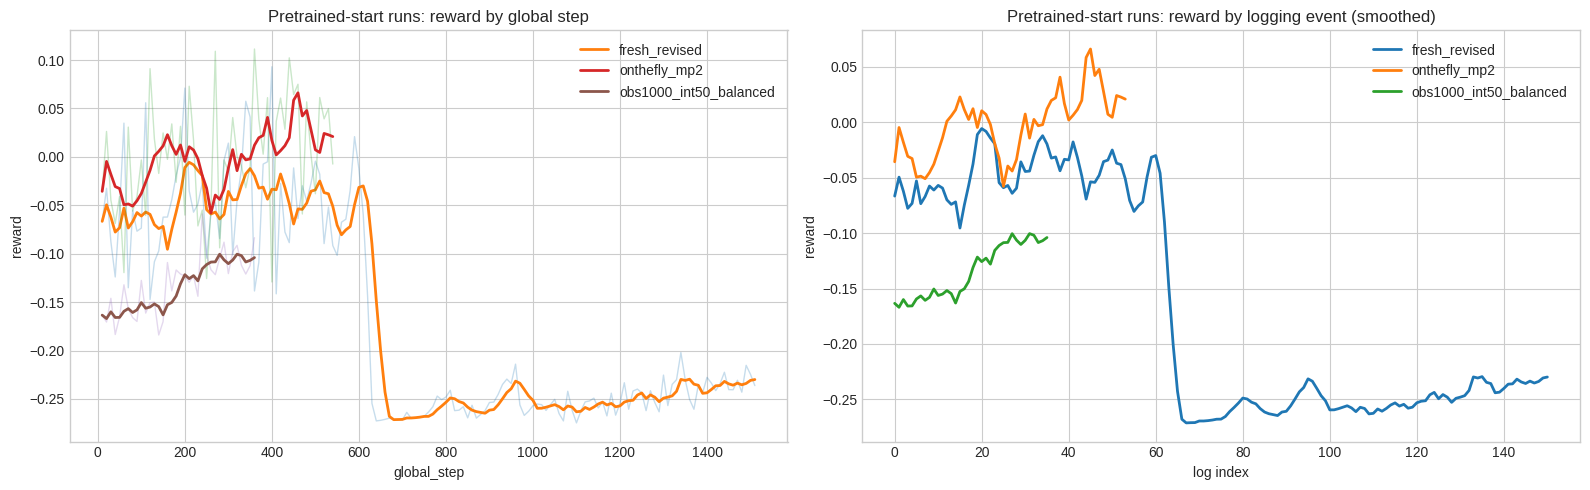

In [13]:
window = 5
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=False)

for name, df in main_run_dfs.items():
    plot_df = df.copy()
    plot_df["reward_smooth"] = plot_df["reward"].rolling(window, min_periods=1).mean()
    axes[0].plot(plot_df["global_step"], plot_df["reward"], alpha=0.25, linewidth=1)
    axes[0].plot(plot_df["global_step"], plot_df["reward_smooth"], linewidth=2, label=name)

    axes[1].plot(plot_df.index, plot_df["reward_smooth"], linewidth=2, label=name)

axes[0].set_title("Pretrained-start runs: reward by global step")
axes[0].set_xlabel("global_step")
axes[0].set_ylabel("reward")
axes[0].legend()

axes[1].set_title("Pretrained-start runs: reward by logging event (smoothed)")
axes[1].set_xlabel("log index")
axes[1].set_ylabel("reward")
axes[1].legend()

plt.tight_layout()


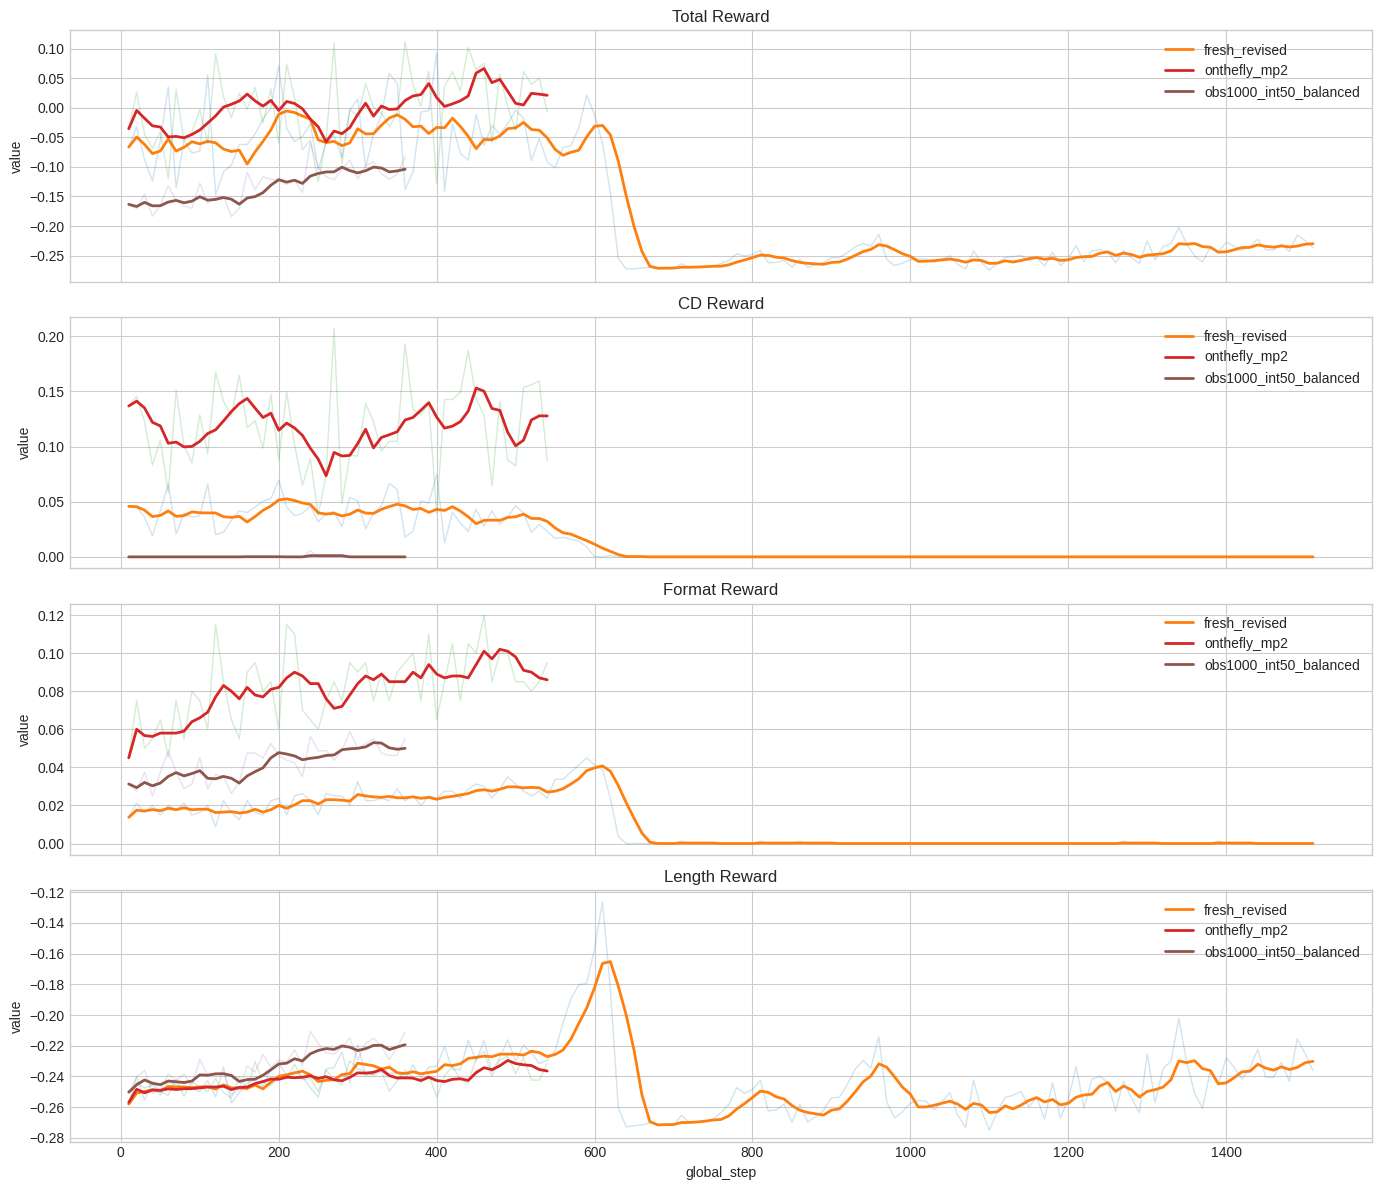

In [14]:
component_cols = [
    "reward",
    "rewards/cd_graph_reward/mean",
    "rewards/cd_format_reward/mean",
    "rewards/length_penalty_reward/mean",
]

title_map = {
    "reward": "Total Reward",
    "rewards/cd_graph_reward/mean": "CD Reward",
    "rewards/cd_format_reward/mean": "Format Reward",
    "rewards/length_penalty_reward/mean": "Length Reward",
}

fig, axes = plt.subplots(len(component_cols), 1, figsize=(14, 12), sharex=True)

for ax, col in zip(axes, component_cols):
    for name, df in main_run_dfs.items():
        if col in df.columns:
            smooth = df[col].rolling(5, min_periods=1).mean()

            ax.plot(
                df["global_step"],
                df[col],
                linewidth=1,
                alpha=0.2,
            )
            ax.plot(
                df["global_step"],
                smooth,
                linewidth=2,
                label=name,
            )

    ax.set_title(title_map[col])
    ax.set_ylabel("value")
    ax.legend()

axes[-1].set_xlabel("global_step")
plt.tight_layout()


### Early vs late summary

This is a compact table for slides or email updates.


In [15]:
segment_rows = []

for name, df in main_run_dfs.items():
    third = max(len(df) // 3, 1)
    first = df.iloc[:third]
    last = df.iloc[-third:]

    segment_rows.append({
        "run": name,
        "early_reward_mean": first["reward"].mean(),
        "late_reward_mean": last["reward"].mean(),
        "reward_gain": last["reward"].mean() - first["reward"].mean(),
        "early_cd_graph_reward": first.get("rewards/cd_graph_reward/mean", pd.Series(dtype=float)).mean(),
        "late_cd_graph_reward": last.get("rewards/cd_graph_reward/mean", pd.Series(dtype=float)).mean(),
        "late_cd_format_reward": last.get("rewards/cd_format_reward/mean", pd.Series(dtype=float)).mean(),
        "late_length_penalty": last.get("rewards/length_penalty_reward/mean", pd.Series(dtype=float)).mean(),
    })

segment_df = pd.DataFrame(segment_rows).sort_values("reward_gain", ascending=False).reset_index(drop=True)
segment_df


,run,early_reward_mean,late_reward_mean,reward_gain,early_cd_graph_reward,late_cd_graph_reward,late_cd_format_reward,late_length_penalty
0,obs1000_int50_balanced,-0.157709,-0.105825,0.051883,0.000000,0.000000,0.050104,-0.220773
1,onthefly_mp2,-0.016123,0.024779,0.040902,0.119513,0.125872,0.091944,-0.237009
2,fresh_revised,-0.045592,-0.245998,-0.200407,0.040542,0.000000,0.000050,-0.246311


### Continuation run

`continue_from_540` is a warm-start continuation from an already trained GRPO checkpoint, so it should not be interpreted as directly comparable to the pretrained-start runs above. Use this subsection to report it separately.


In [16]:
continuation_summary_rows = []

for name, df in continuation_run_dfs.items():
    first = df.iloc[0]
    last = df.iloc[-1]
    best_idx = df["reward"].idxmax()
    best = df.loc[best_idx]

    continuation_summary_rows.append({
        "run": name,
        "num_logged_steps": len(df),
        "first_global_step": first["global_step"],
        "last_global_step": last["global_step"],
        "first_reward": first["reward"],
        "best_reward": best["reward"],
        "best_reward_step": best["global_step"],
        "last_reward": last["reward"],
        "delta_last_minus_first": last["reward"] - first["reward"],
        "last_cd_graph_reward": last.get("rewards/cd_graph_reward/mean"),
    })

continuation_summary_df = pd.DataFrame(continuation_summary_rows)
continuation_summary_df


,run,num_logged_steps,first_global_step,last_global_step,first_reward,best_reward,best_reward_step,last_reward,delta_last_minus_first,last_cd_graph_reward
0,continue_from_540,132,10.0,1320.0,-0.052347,0.139347,400.0,-0.272821,-0.220474,0.0


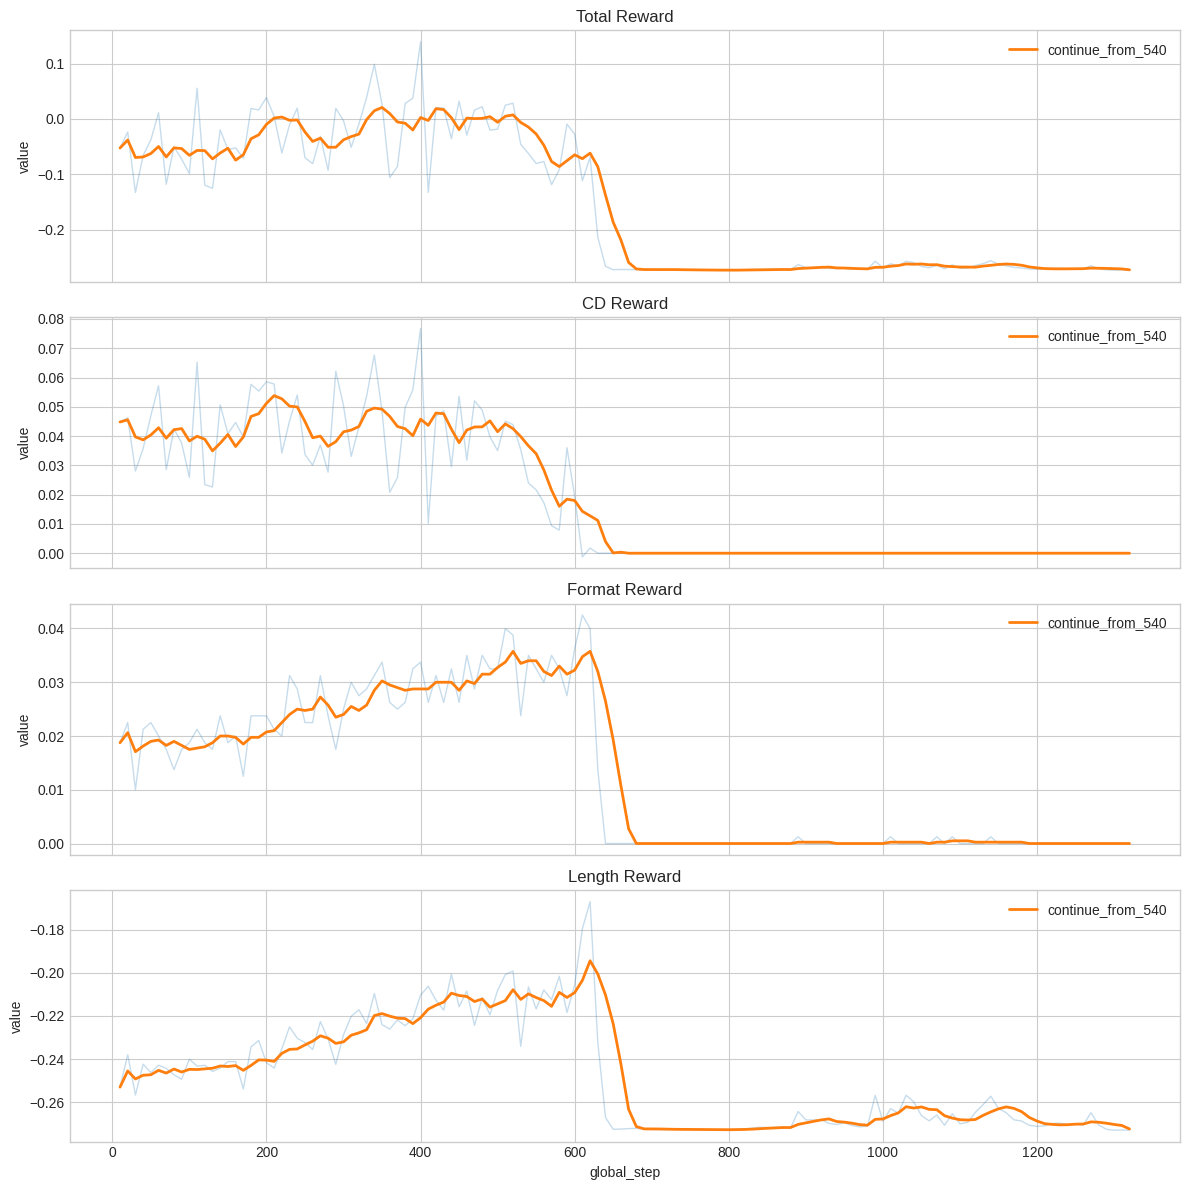

In [17]:
component_cols = [
    "reward",
    "rewards/cd_graph_reward/mean",
    "rewards/cd_format_reward/mean",
    "rewards/length_penalty_reward/mean",
]

title_map = {
    "reward": "Total Reward",
    "rewards/cd_graph_reward/mean": "CD Reward",
    "rewards/cd_format_reward/mean": "Format Reward",
    "rewards/length_penalty_reward/mean": "Length Reward",
}

window = 5
fig, axes = plt.subplots(len(component_cols), 1, figsize=(12, 12), sharex=True)

for ax, col in zip(axes, component_cols):
    for name, df in continuation_run_dfs.items():
        if col in df.columns:
            plot_df = df.copy()
            smooth = plot_df[col].rolling(window, min_periods=1).mean()

            ax.plot(
                plot_df["global_step"],
                plot_df[col],
                alpha=0.25,
                linewidth=1,
            )
            ax.plot(
                plot_df["global_step"],
                smooth,
                linewidth=2,
                label=name,
            )

    ax.set_title(title_map[col])
    ax.set_ylabel("value")
    ax.legend()

axes[-1].set_xlabel("global_step")
plt.tight_layout()
